##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [20]:
import os
import cv2
import random
import subprocess
import numpy as np
import datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline

from collections import deque
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from IPython.display import Image as IPImage

In [2]:
SEED = 23
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
#My path of the dataset is /Users/shadenkhalud/Downloads
DATASET_DIR = 'action_youtube_naudio'

assert os.path.isdir(DATASET_DIR), (
    f"Dataset not found at: {DATASET_DIR}\n"
    "'action_youtube_naudio' is not in the lab folder folder!"
)

In [8]:
#List class folders
all_classes = sorted(
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d)) and not d.startswith('.')
)

print(f'Dataset found at: {DATASET_DIR}')
print(f'\nAvailable classes ({len(all_classes)}):')
print(all_classes)

Dataset found at: action_youtube_naudio

Available classes (11):
['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']


In [9]:
IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64
MAX_IMAGES_PER_CLASS = 6000

CLASSES_LIST = ['basketball', 'biking', 'tennis_swing']
NUM_CLASSES  = len(CLASSES_LIST)

#some folders to skip when going through each class folder/directory
SKIP_DIRS = {'Annotation'} # annotation sub-folders contain only .xgtf files
SKIP_EXTS = {'.xgtf', '.txt'} # non-video files :)
VIDEO_EXTS = {'.avi'} # use .avi only; some classes have .mpg duplicates

#verify class folder actually exists
for cls in CLASSES_LIST:
    path = os.path.join(DATASET_DIR, cls)
    assert os.path.isdir(path), f'Class folder not found: {path}'

print(f'Config ready :) Training on {NUM_CLASSES} classes: {CLASSES_LIST}')

Config ready :) Training on 3 classes: ['basketball', 'biking', 'tennis_swing']


In [10]:
def get_first_video(class_name):
    """
    Go through class name > group folders > return the first .avi file found
    """
    class_path = os.path.join(DATASET_DIR, class_name)
    for root, dirs, files in os.walk(class_path):
        dirs[:] = sorted(d for d in dirs if d not in SKIP_DIRS and not d.startswith('.'))
        for fname in sorted(files):
            ext = os.path.splitext(fname)[1].lower()
            if ext in VIDEO_EXTS:
                return os.path.join(root, fname)
    return None

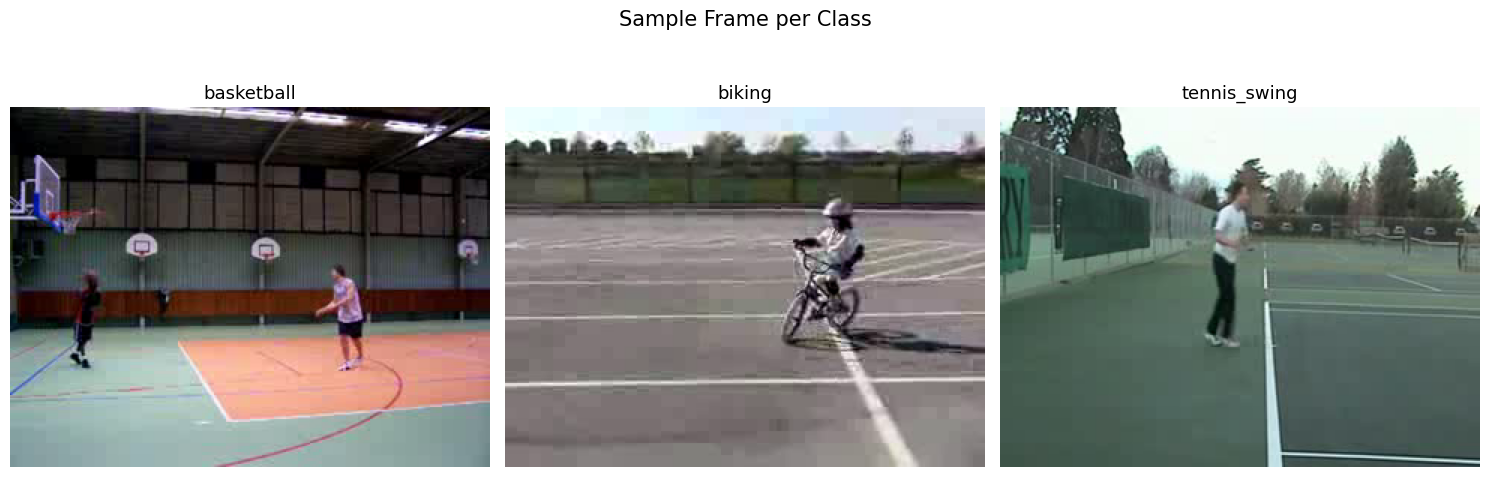

In [11]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))

for ax, cls in zip(axes, CLASSES_LIST):
    video_path = get_first_video(cls)

    if video_path is None:
        ax.set_title(f'{cls}\n(no video found)', color='red')
        ax.axis('off')
        continue

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(cls, fontsize=13)
    else:
        ax.set_title(f'{cls}\n(could not read)', color='orange')
    ax.axis('off')

plt.suptitle('Sample Frame per Class', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
def collect_video_paths(class_name):
    """
    return a list of all .avi file paths inside a class folder :)
    """
    paths = []
    class_path = os.path.join(DATASET_DIR, class_name)
    for root, dirs, files in os.walk(class_path):
        dirs[:] = sorted(d for d in dirs if d not in SKIP_DIRS and not d.startswith('.'))
        for fname in files:
            ext = os.path.splitext(fname)[1].lower()
            if ext in VIDEO_EXTS:
                paths.append(os.path.join(root, fname))
    return paths

In [13]:
def frames_extraction(video_path):
    """
    read all frames from a video, resize to (IMAGE_HEIGHT x IMAGE_WIDTH) which I have set earlier
    and normalise pixel values to [0, 1]
    """
    frames = []
    cap = cv2.VideoCapture(video_path)
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        resized    = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
        normalized = (resized / 255.0).astype(np.float32)
        frames.append(normalized)
    cap.release()
    return frames #returns a list of float32 numpy arrays

In [14]:
def create_dataset():
    """
    build the feature matrix and label vector for all chosen classes
    this will return
    1. features : np.ndarray  shape (N, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
    2. labels : np.ndarray  shape (N,) integer class indices
    """
    all_features, all_labels = [], []

    for class_idx, class_name in enumerate(CLASSES_LIST):
        print(f'  [{class_idx}] Processing "{class_name}"')

        video_paths = collect_video_paths(class_name)
        temp_frames = []

        for vp in video_paths:
            temp_frames.extend(frames_extraction(vp))

        #can NOT sample more frames than we actually have! :)
        sample_count = min(MAX_IMAGES_PER_CLASS, len(temp_frames))
        sampled      = random.sample(temp_frames, sample_count)

        all_features.extend(sampled)
        all_labels.extend([class_idx] * sample_count)

        print(f'       {len(video_paths):3d} videos | '
              f'{len(temp_frames):6d} total frames | '
              f'{sample_count:6d} sampled')

    return (
        np.array(all_features, dtype=np.float32),
        np.array(all_labels,   dtype=np.int32)
    )

In [15]:
print('building dataset')
features, labels = create_dataset()
print(f'\nDataset ready -- features: {features.shape}  |  labels: {labels.shape}')

building dataset
  [0] Processing "basketball"
       141 videos |  15092 total frames |   6000 sampled
  [1] Processing "biking"
       145 videos |  25272 total frames |   6000 sampled
  [2] Processing "tennis_swing"
       167 videos |  24096 total frames |   6000 sampled

Dataset ready -- features: (18000, 64, 64, 3)  |  labels: (18000,)


In [16]:
one_hot_labels = to_categorical(labels, num_classes=NUM_CLASSES)

dist = {CLASSES_LIST[i]: int((labels == i).sum()) for i in range(NUM_CLASSES)}
print(f'One-hot shape: {one_hot_labels.shape}')
print(f'Class distribution: {dist}')

One-hot shape: (18000, 3)
Class distribution: {'basketball': 6000, 'biking': 6000, 'tennis_swing': 6000}


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    features, one_hot_labels,
    test_size=0.2,
    shuffle=True,
    random_state=SEED
)

print(f'Train : X={X_train.shape}  y={y_train.shape}')
print(f'Test  : X={X_test.shape}   y={y_test.shape}')

Train : X=(14400, 64, 64, 3)  y=(14400, 3)
Test  : X=(3600, 64, 64, 3)   y=(3600, 3)


In [18]:
def create_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),


        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),


        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),


        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        #classification head
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.summary()
    return model


model = create_model()
print('\nModel created ;)')

/opt/anaconda3/envs/action-recognition/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,899 (1.74 MB)

 Trainable params: 455,939 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)


Model created ;)


In [22]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, mode='min',
    restore_best_weights=True, verbose=1
)
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4,
    min_lr=1e-6, verbose=1
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    shuffle=True,
    validation_split=0.15,
    callbacks=[early_stop, lr_reducer]
)

print('\nTraining complete :)')

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 98s 243ms/step - accuracy: 0.9322 - loss: 0.1829 - val_accuracy: 0.5046 - val_loss: 2.7519 - learning_rate: 0.0010
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 93s 242ms/step - accuracy: 0.9890 - loss: 0.0329 - val_accuracy: 0.9630 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 109s 285ms/step - accuracy: 0.9905 - loss: 0.0305 - val_accuracy: 0.5787 - val_loss: 2.4072 - learning_rate: 0.0010
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 100s 261ms/step - accuracy: 0.9968 - loss: 0.0095 - val_accuracy: 0.8949 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 95s 248ms/step - accuracy: 0.9984 - loss: 0.0053 - val_accuracy: 0.9981 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 93s 243ms/step - accuracy: 0.9889 - loss: 0.0339 - val_accuracy: 0.6708 - val_loss: 1.5646 - learning_rate: 0.0010
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 90s 234ms/step - accuracy: 0

In [23]:
student_name = 'Shaden'
save_path    = f'{student_name}_ucf11_model.h5'

model.save(save_path)
print(f'Model saved as: {save_path}')

Model saved as: Shaden_ucf11_model.h5


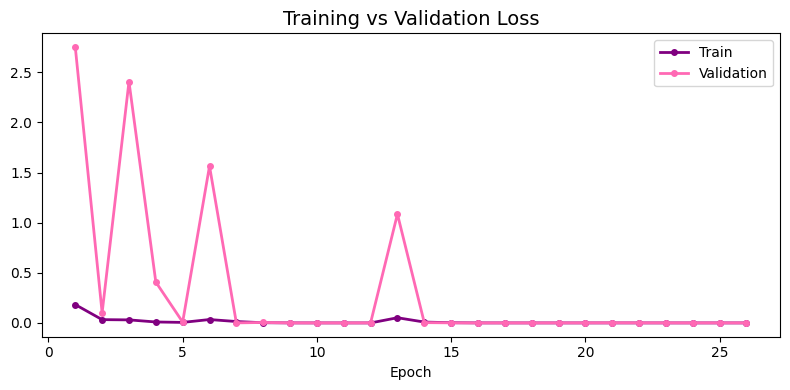

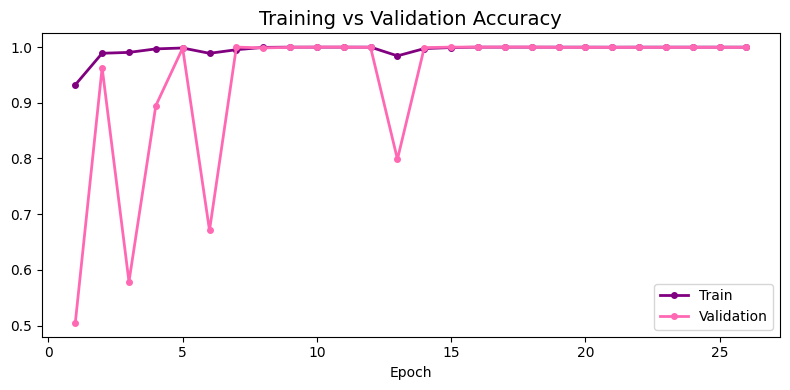

In [24]:
def plot_metric(train_vals, val_vals, title):
    epochs = range(1, len(train_vals) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_vals, color='purple', linewidth=2, marker='o', markersize=4, label='Train')
    plt.plot(epochs, val_vals,   color='hotpink', linewidth=2, marker='o', markersize=4, label='Validation')
    plt.title(title, fontsize=14)
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_metric(history.history['loss'], history.history['val_loss'],
            'Training vs Validation Loss')
plot_metric(history.history['accuracy'], history.history['val_accuracy'],
            'Training vs Validation Accuracy')

In [25]:
os.makedirs('Youtube_Videos', exist_ok=True)

VIDEO_URLS = {
    'basketball' : 'https://youtube.com/shorts/KRoSohvCyok?si=JmUo1DIybvXaUDRo',
    'biking' : 'https://youtube.com/shorts/4Ud2sDzQYKI?si=_iMosZokvhjY-VcF',
    'tennis_swing' : 'https://youtube.com/shorts/xXNFSn_GU7Y?si=5Qq4ueLhT5M6sjiP',
}

for action, url in VIDEO_URLS.items():
    out_path = f'Youtube_Videos/{action}.mp4'
    if os.path.exists(out_path):
        print(f'  Already exists: {out_path} — skipping.')
        continue
    print(f'Downloading "{action}" ...')
    result = subprocess.run(
        ['yt-dlp', '-f', 'mp4', '-o', out_path, '--no-playlist', url],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'Saved → {out_path}')
    else:
        print(f'Failed:\n{result.stderr}')

print('\nDone.')

Saved → Youtube_Videos/basketball.mp4
Saved → Youtube_Videos/biking.mp4
Saved → Youtube_Videos/tennis_swing.mp4

Done.


In [27]:
def predict_on_video(video_file_path, output_file_path, window_size=25):
    """
    run the model frame by frame :)
    + overlay the rolling-average predicted class + confidence on each frame, write the annotated video to output_file_path
    """
    prob_deque = deque(maxlen=window_size)

    cap    = cv2.VideoCapture(video_file_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 24

    writer = cv2.VideoWriter(
        output_file_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (width, height)
    )

    frame_count = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_count += 1

        resized    = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
        normalized = resized.astype(np.float32) / 255.0
        probs      = model.predict(np.expand_dims(normalized, axis=0), verbose=0)[0]
        prob_deque.append(probs)

        if len(prob_deque) == window_size:
            avg_probs  = np.array(prob_deque).mean(axis=0)
            pred_idx   = int(np.argmax(avg_probs))
            pred_class = CLASSES_LIST[pred_idx]
            confidence = avg_probs[pred_idx]
            label      = f'{pred_class}  {confidence * 100:.1f}%'
            cv2.putText(frame, label, (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 200, 50), 2, cv2.LINE_AA)

        writer.write(frame)

    cap.release()
    writer.release()
    print(f'  {frame_count} frames processed > {output_file_path}')


#run on all 3 youtube videos
WINDOW_SIZE = 25

for action in CLASSES_LIST:
    in_path  = f'Youtube_Videos/{action}.mp4'
    out_path = f'Youtube_Videos/{action}_predicted_ws{WINDOW_SIZE}.mp4'

    if os.path.exists(in_path):
        print(f'\nPredicting on "{action}" ')
        predict_on_video(in_path, out_path, window_size=WINDOW_SIZE)
    else:
        print(f'\n  "{in_path}" not found — add the video and re-run !')

print('\nAll predictions complete')


Predicting on "basketball" 
  452 frames processed > Youtube_Videos/basketball_predicted_ws25.mp4

Predicting on "biking" 
  433 frames processed > Youtube_Videos/biking_predicted_ws25.mp4

Predicting on "tennis_swing" 
  291 frames processed > Youtube_Videos/tennis_swing_predicted_ws25.mp4

All predictions complete


In [29]:
def make_average_predictions(video_file_path, num_sample_frames=50):
    """
    sample num_sample_frames evenly-spaced frames, average the model's
    softmax outputs, and print a ranked class-probability table
    """
    probs_matrix = np.zeros((num_sample_frames, NUM_CLASSES), dtype=np.float32)

    cap = cv2.VideoCapture(video_file_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    skip = max(1, total_frames // num_sample_frames)

    for i in range(num_sample_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        ok, frame = cap.read()
        if not ok:
            break
        resized = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
        normalized = resized.astype(np.float32) / 255.0
        probs  = model.predict(np.expand_dims(normalized, axis=0), verbose=0)[0]
        probs_matrix[i] = probs

    cap.release()

    avg_probs  = probs_matrix.mean(axis=0)
    ranked_idx = np.argsort(avg_probs)[::-1]

    print(f"  {'CLASS':<20} {'AVG PROBABILITY':>16}  BAR")
    print(f"  {'-'*52}")
    for idx in ranked_idx:
        bar  = '#' * int(avg_probs[idx] * 30)
        print(f"  {CLASSES_LIST[idx]:<20} {avg_probs[idx]*100:>8.2f}%   {bar}")


for action in CLASSES_LIST:
    in_path = f'Youtube_Videos/{action}.mp4'
    if os.path.exists(in_path):
        print(f'\n{"-"*55}')
        print(f'  Video: {action}')
        make_average_predictions(in_path, num_sample_frames=50)
    else:
        print(f'\n  "{in_path}" not found — skipping.')


-------------------------------------------------------
  Video: basketball
  CLASS                 AVG PROBABILITY  BAR
  ----------------------------------------------------
  biking                  90.39%   ###########################
  basketball               9.45%   ##
  tennis_swing             0.16%   

-------------------------------------------------------
  Video: biking
  CLASS                 AVG PROBABILITY  BAR
  ----------------------------------------------------
  biking                  98.39%   #############################
  basketball               1.61%   
  tennis_swing             0.00%   

-------------------------------------------------------
  Video: tennis_swing
  CLASS                 AVG PROBABILITY  BAR
  ----------------------------------------------------
  tennis_swing            90.74%   ###########################
  basketball               9.25%   ##
  biking                   0.00%   


while validating the model on three external YouTube videos
the model correctly identified biking and tennis swing while misclassifying the basketball video as biking which could be due to the YouTube video's filming style 
Overall, the model demonstrated strong generalization on two out of three classes, with the single misclassification that might be related to the inherent limitations of a single frame CNN approach rather than a failure in training
